In [16]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
from collections import defaultdict
from typing import Any, Callable, Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pmdarima as pm
import scipy.stats as sps
import seaborn as sns
import statsmodels
import statsmodels.api as sm
import sys
import torch
import tsfresh
from catboost import CatBoostRegressor
from IPython.display import HTML, clear_output, display
from prophet import Prophet
from pylab import rcParams
from sktime.split import ExpandingWindowSplitter
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
)
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from statsforecast import models as sf_models
from statsforecast.models import (
    SimpleExponentialSmoothing,
    SimpleExponentialSmoothingOptimized,
)
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt, SimpleExpSmoothing
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from torch import nn
from torch.utils.data import DataLoader, Dataset, random_split
from tqdm import tqdm
from tqdm.auto import tqdm as auto_tqdm
from tsfresh import extract_features, select_features
from tsfresh.feature_extraction import settings
from tsfresh.utilities.dataframe_functions import impute, roll_time_series

# Visualization setup
sns.set(font_scale=1.3, palette="Set2")
rcParams['figure.figsize'] = 15, 7
%matplotlib inline
from utils.vis import plot_dist_matrix
from utils.misc import save_dict_as_json
from utils.data_transform import take_diff
from utils.clusterization import build_coint_mat, cluster_from_distance_matrix, get_linear_clusters
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from utils.models import ClusterModel, DummyConditionalModel, MixModel
from utils.vis import plot_error_matrix, plot_model_pred, calc_average_error
from utils.interface import cross_validate_model, calc_avg_error, build_error_matrix, build_short_error_matrix

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
df = pd.read_csv(
    "/home/danilach/mipt-stats/SberTs/Data/comb_df_v1.csv", index_col=0
)
df.index = pd.to_datetime(df.index)

df = pd.read_csv("/home/danilach/mipt-stats/SberTs/Data/comb_df_v1.csv", index_col=0)
df.index = pd.to_datetime(df.index)
df = df.drop(
    columns=[
        "Огурцы тепличные, руб./кг",
        "Томаты тепличные, руб./кг",
    ]
)

In [18]:
horizon_list = [12]

matrix_params = {
    "model_class": MixModel,
    "df": df,
    "horizon": 12,
    "stride": 24,
    "start_window": 60,
    "model_params": {},
}

In [19]:
naive_model_matrices = {}

clust_matrix = build_error_matrix(**matrix_params)

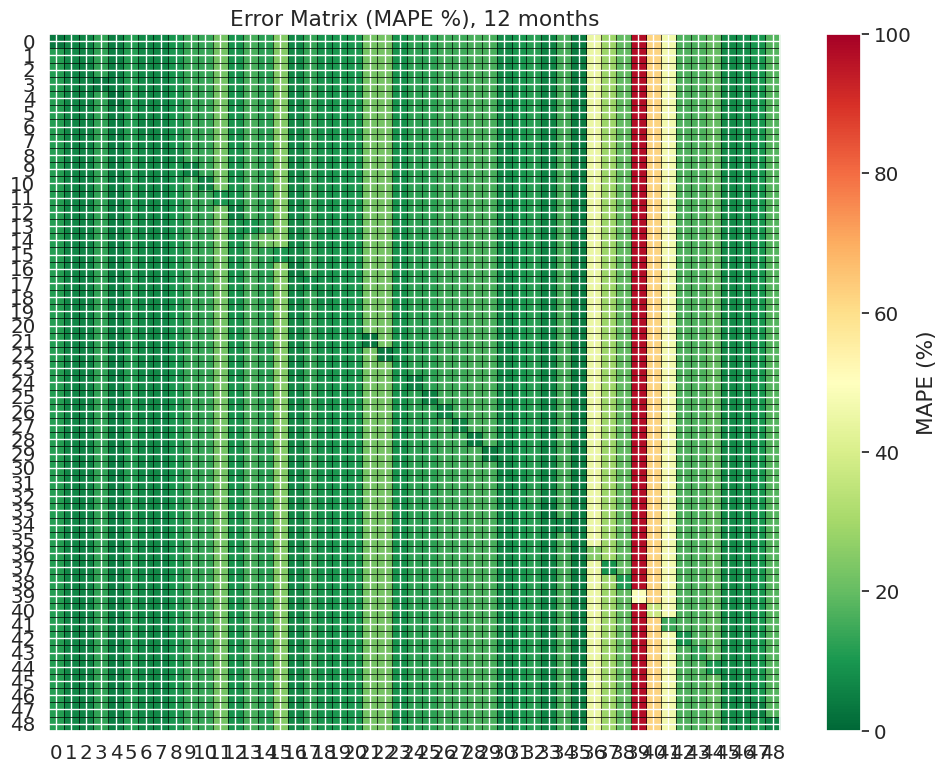

In [20]:
plot_error_matrix(clust_matrix, title=f"Error Matrix (MAPE %), 12 months")

In [21]:
calc_average_error(clust_matrix)

16.91%
